In [2]:
from google.colab import files
files.upload()

Saving WhatsApp Image 2026-02-26 at 13.46.59.jpeg to WhatsApp Image 2026-02-26 at 13.46.59 (1).jpeg


{'WhatsApp Image 2026-02-26 at 13.46.59 (1).jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x02\x02\x02\x03\x02\x02\x02\x03\x03\x03\x03\x04\x06\x04\x04\x04\x04\x04\x08\x06\x06\x05\x06\t\x08\n\n\t\x08\t\t\n\x0c\x0f\x0c\n\x0b\x0e\x0b\t\t\r\x11\r\x0e\x0f\x10\x10\x11\x10\n\x0c\x12\x13\x12\x10\x13\x0f\x10\x10\x10\xff\xdb\x00C\x01\x03\x03\x03\x04\x03\x04\x08\x04\x04\x08\x10\x0b\t\x0b\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\xff\xc0\x00\x11\x08\x01\xe0\x02\x80\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\x

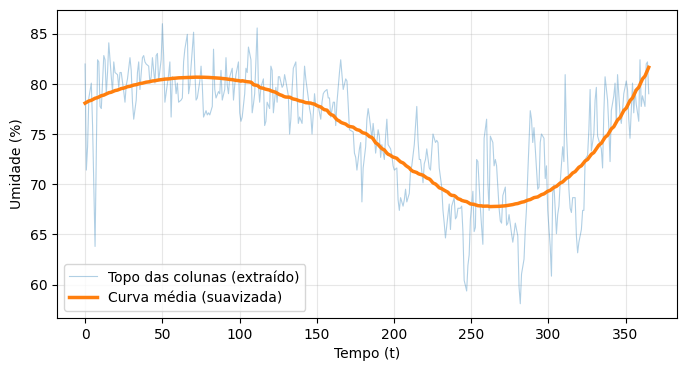

u_hat(200) ≈ 72.67876294883197


In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# -----------------------------
# 1) Lê a imagem
# -----------------------------
img_path = "/content/WhatsApp Image 2026-02-26 at 13.46.59.jpeg"
arr = np.array(Image.open(img_path).convert("RGB"))
r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]

# -----------------------------
# 2) Máscara do azul (colunas)
#    Ajuste fino se necessário
# -----------------------------
blue = (b > 150) & (r < 120) & (g < 160)

# -----------------------------
# 3) Encontra a faixa em x onde há barras (região do gráfico)
# -----------------------------
counts_x = blue.sum(axis=0)
xs = np.where(counts_x > 50)[0]  # limiar
x0, x1 = xs.min(), xs.max()

# -----------------------------
# 4) Encontra bordas (topo/fundo) do retângulo do eixo pelo preto
# -----------------------------
dark = np.all(arr < 60, axis=2)
dark_counts_y = dark[:, x0:x1+1].sum(axis=1)
# duas linhas mais "pretas" = topo e fundo do retângulo do eixo
y_candidates = np.argsort(dark_counts_y)[-5:]
y_top, y_bottom = np.sort(y_candidates)[0], np.sort(y_candidates)[-1]

# -----------------------------
# 5) Para cada x, pega o topo da barra (menor y com pixel azul)
# -----------------------------
x_pix = np.arange(x0, x1+1)
top_y = np.full_like(x_pix, np.nan, dtype=float)

for i, x in enumerate(x_pix):
    ys = np.where(blue[:, x])[0]
    if ys.size:
        top_y[i] = ys.min()

valid = ~np.isnan(top_y)
x_pix = x_pix[valid]
top_y = top_y[valid]

# -----------------------------
# 6) Converte pixel -> (t, umidade)
#    IMPORTANTE: aqui é aproximação!
#    Ajuste tmax e ymax conforme seu eixo real.
# -----------------------------
tmax  = 365.0     # seu eixo x parece 0..365
ymax  = 90.0      # seu eixo y parece 0..80 e "um topo" ~90 (ajuste p/ 100 se quiser)

t = (x_pix - x0) / (x1 - x0) * tmax
u = (y_bottom - top_y) / (y_bottom - y_top) * ymax

# -----------------------------
# 7) Suaviza e cria função u_hat(t)
# -----------------------------
win  = 201   # janela ímpar (aumente p/ mais liso)
poly = 3
u_smooth = savgol_filter(u, window_length=win, polyorder=poly)

u_hat = interp1d(t, u_smooth, kind="cubic", fill_value="extrapolate")

# -----------------------------
# 8) Visualização
# -----------------------------
tt = np.linspace(t.min(), t.max(), 600)
plt.figure(figsize=(8,4))
plt.plot(t, u, lw=0.8, alpha=0.35, label="Topo das colunas (extraído)")
plt.plot(t, u_smooth, lw=2.5, label="Curva média (suavizada)")
plt.xlabel("Tempo (t)")
plt.ylabel("Umidade (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Exemplo de uso da função:
print("u_hat(200) ≈", float(u_hat(200)))

In [15]:
delta = 5.0
u_hat_shift = lambda tt: u_hat(tt) - delta

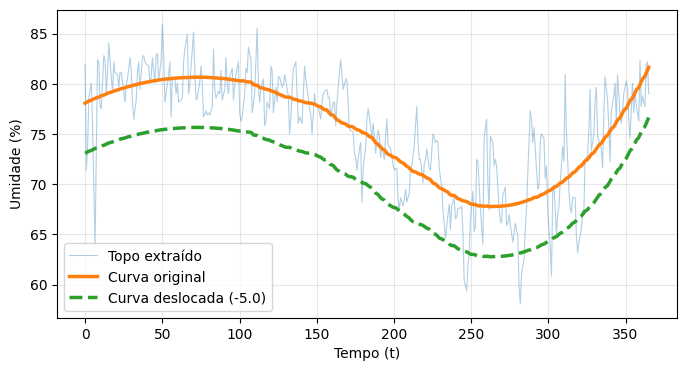

In [17]:
tt = np.linspace(t.min(), t.max(), 600)
plt.figure(figsize=(8,4))
plt.plot(t, u, lw=0.8, alpha=0.35, label="Topo extraído")
plt.plot(tt, u_hat(tt), lw=2.5, label="Curva original")
plt.plot(tt, u_hat_shift(tt), lw=2.5, ls="--", label=f"Curva deslocada (-{delta})")
plt.xlabel("Tempo (t)")
plt.ylabel("Umidade (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()